In [1]:


# %%
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
#from numba import cuda
import zuko
from helpers.models.DNN import count_parameters
from helpers.data_transforms import (
    preprocess_data,
    inverse_preprocess_data,
    inverse_preprocess_data_torch,
    load_in_data,
)
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples
from helpers.flow import sample_from_flow
plt.style.use("../science.mplstyle")
from helpers.material_map import torch_barrel_material_penalty

# %%
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

# %%


BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5

In [2]:


feature_indices_dict = {
    "InnerTrackerBarrelCollection": {"r": 2, "phi": 3, "z": 4, "side": 5, "layer": 6},
    "InnerTrackerEndcapCollection": {"r": 2, "phi": 3, "z": 4, "side": 5, "layer": 6},
    "OuterTrackerBarrelCollection": {"r": 2, "phi": 3, "z": 4, "side": 5, "layer": 6},
    "OuterTrackerEndcapCollection": {"r": 2, "phi": 3, "z": 4, "side": 5, "layer": 6},
    "VertexBarrelCollection": {"r": 2, "phi": 3, "z": 4, "side": 5, "layer": 6},
    "VertexEndcapCollection": {"r": 2, "phi": 3, "z": 4, "side": 5, "layer": 6},
}


WORKING_DIR = "/pscratch/sd/r/rmastand/muon_collider"
ZUKO_ID = "NCSF"
NAME = "TEST"
SEED = 8
COLLECTION_LIST = "OuterTrackerBarrelCollection"
NUM_EPOCHS = 200
TRANSFORMS = 5 
FREQS = 5
HIDDEN_FEATURES = "128,128,128" 
TRAIN_FLOW = True  
EVAL_FLOW = True  
BATCH_SIZE = 4096 
LEARNING_RATE = 0.0001
NUM_COND_INPUTS = 2   
FEATURE_ORDER  = "0,4,1,2,3,6,7" 
BINS = 48  
DEGREE = 4
POLYNOMIALS = 5  
FEATURES = "rphi"
TRAINING_FRAC = 1
PHI_LOCAL = False
PLOT_EPOCH_INTERVAL = 1

lambda_material = 1 / BATCH_SIZE



In [3]:




# %%
save_dir = f"{WORKING_DIR}/zuko_outputs/{ZUKO_ID}/{NAME}"
os.makedirs(save_dir, exist_ok=True)



# %%

# computing
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [4]:


collection_list = [x for x in COLLECTION_LIST.split(",")]
print(collection_list)


log_vars = []

# %%
FEATURE_ORDER = None if FEATURE_ORDER is None else [int(x) for x in FEATURE_ORDER.split(",")]
X, feature_labels = load_in_data(collection_list, FEATURES, WORKING_DIR, TRAINING_FRAC, NUM_COND_INPUTS, feature_order=FEATURE_ORDER, use_local_phi=PHI_LOCAL)
print(f"Data has shape {X.shape}")
print("Feature labels:", feature_labels)
NUM_FEATURES = X.shape[1] - NUM_COND_INPUTS


bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(X.shape[1])}

for i in range(X.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(X[:,i])), np.log10(1.1*np.max(X[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(X[:,i] - 1), np.max(X[:,i] + 1), NUM_BINS) 


fig_samp, axes_samp = plot_corner_hist_2d(
        X,
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= "data",
    )
plt.savefig(f"{save_dir}/data_final")
plt.close()


['OuterTrackerBarrelCollection']
Data has shape (3280678, 7)
Feature labels: ['log($E$) [Gev]', '$t$', '$r$', '$\\phi$', '$z$', 'side (cond)', 'layer (cond)']


In [5]:

# %%


X_preproc = preprocess_data(X, save_dir, ZUKO_ID, NUM_COND_INPUTS)

# plot_hists_1d({"data":data}, bins_dict, log_dims=log_vars, labels=feature_labels)
# plt.show()

# plot_hists_1d({"data":X_preproc}, bins_dict_preproc, log_dims=[], labels = feature_labels)
# plt.show()





# %%
# train val split
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X_preproc, test_size=0.2, random_state=42)


print(f"Train data has shape {X_train.shape}.")
print(f"Val data has shape {X_val.shape}.")

train_loader = torch.utils.data.DataLoader(X_train, batch_size=BATCH_SIZE, shuffle=True, num_workers = 8, pin_memory = True)
val_loader = torch.utils.data.DataLoader(X_val, batch_size=BATCH_SIZE, shuffle=False, num_workers = 8, pin_memory = True)

# %%

Train data has shape (2624542, 7).
Val data has shape (656136, 7).


In [6]:



hidden_features = [int(x) for x in HIDDEN_FEATURES.split(",")]

if ZUKO_ID == "NSF":
    flow = zuko.flows.NSF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features).to(device)
#elif ZUKO_ID == "GMM":
#    flow = zuko.flows.GMM(NUM_FEATURES, NUM_COND_INPUTS, components=30, hidden_features=[256] * 5).to(device)
#elif ZUKO_ID == "NICE":
#    flow = zuko.flows.NICE(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features).to(device)
elif ZUKO_ID == "MAF":
   flow = zuko.flows.MAF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features).to(device)
elif ZUKO_ID == "NCSF":
    flow = zuko.flows.NCSF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features, bins=BINS).to(device)
elif ZUKO_ID == "SOSPF":
    flow = zuko.flows.SOSPF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features, degree=DEGREE, polynomials=POLYNOMIALS).to(device)
#elif ZUKO_ID == "NAF":
#    flow = zuko.flows.NAF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features).to(device)
elif ZUKO_ID == "UNAF":
    flow = zuko.flows.UNAF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features).to(device)
elif ZUKO_ID == "CNF":
    flow = zuko.flows.CNF(NUM_FEATURES, NUM_COND_INPUTS, hidden_features=hidden_features, freqs=FREQS).to(device)
#elif ZUKO_ID == "GF":
#    flow = zuko.flows.GF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features, components=8).to(device)
#elif ZUKO_ID == "BPF":
#    flow = zuko.flows.BPF(NUM_FEATURES, NUM_COND_INPUTS, transforms=TRANSFORMS, hidden_features=hidden_features, degree=16).to(device)
else:
    print("ERROR: Unknown ZUKO_ID")
    exit()


num_params = count_parameters(flow)
print(f"Number of trainable parameters: {num_params}")


checkpoint_path = f"/pscratch/sd/r/rmastand/muon_collider/zuko_outputs/NCSF/TEST/latest_good_step11923.pt"

state_dict = torch.load(checkpoint_path, map_location=device)

flow.load_state_dict(state_dict)



Number of trainable parameters: 631415


<All keys matched successfully>

In [7]:
def run_training_step(data_loader, epoch, global_step, is_val_step=False):
    flow.eval() if is_val_step else flow.train()

    text_desc = "val" if is_val_step else "train"
    losses_ll, losses_mmap, losses_total = [], [], []
    bad_fracs_preproc = []
    bad_fracs_phys = []

    pbar = tqdm(data_loader, desc=f"{text_desc} batches", leave=False)

    for x in pbar:
        if not is_val_step:
            optimizer.zero_grad(set_to_none=True)

        x = x.to(device).float()

        if NUM_COND_INPUTS > 0:
            x_data = x[:, :-NUM_COND_INPUTS]
            x_context = x[:, -NUM_COND_INPUTS:]
            dist = flow(x_context)
        else:
            x_data = x
            x_context = None
            dist = flow()

        # -----------------------------
        # Check parameters before loss
        # -----------------------------
        bad_param = False

        for name, p in flow.named_parameters():
            if not torch.isfinite(p).all():
                print("\nNON-FINITE FLOW PARAMETER")
                print(name)
                print("finite frac:", torch.isfinite(p).float().mean().item())
                bad_param = True

        if bad_param:
            torch.save(
                {
                    "epoch": epoch,
                    "global_step": global_step,
                    "model_state_dict": flow.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict() if not is_val_step else None,
                },
                f"{save_dir}/nan_params_epoch{epoch}_step{global_step}.pt",
            )
            raise RuntimeError("Flow parameters became non-finite.")

        # -----------------------------
        # Log likelihood loss
        # -----------------------------
        log_prob = dist.log_prob(x_data)
        loss_ll = -log_prob.mean()

        if not torch.isfinite(loss_ll):
            debug_path = f"{save_dir}/nan_debug_epoch{epoch}_step{global_step}.pt"
            model_path = f"{save_dir}/nan_model_epoch{epoch}_step{global_step}.pt"

            bad_lp_mask = ~torch.isfinite(log_prob)
            bad_x_mask = ~torch.isfinite(x_data).all(dim=1)

            torch.save(
                {
                    "epoch": epoch,
                    "global_step": global_step,
                    "model_state_dict": flow.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict() if not is_val_step else None,
                },
                model_path,
            )

            torch.save(
                {
                    "epoch": epoch,
                    "global_step": global_step,
                    "loss_ll": loss_ll.detach().cpu(),
                    "log_prob": log_prob.detach().cpu(),
                    "bad_log_prob_mask": bad_lp_mask.detach().cpu(),
                    "bad_x_mask": bad_x_mask.detach().cpu(),
                    "x_full": x.detach().cpu(),
                    "x_data": x_data.detach().cpu(),
                    "x_context": None if x_context is None else x_context.detach().cpu(),
                    "bad_x_data": x_data[bad_lp_mask | bad_x_mask].detach().cpu(),
                    "bad_x_context": None if x_context is None else x_context[bad_lp_mask | bad_x_mask].detach().cpu(),
                },
                debug_path,
            )

            print("\nLL LOSS BECAME NON-FINITE")
            print("epoch:", epoch)
            print("global_step:", global_step)
            print("loss_ll:", loss_ll.item())
            print("num bad log_prob:", bad_lp_mask.sum().item(), "/", len(log_prob))
            print("num bad x_data:", bad_x_mask.sum().item(), "/", len(x_data))
            print("saved model:", model_path)
            print("saved debug batch:", debug_path)

            if bad_lp_mask.any():
                bad_idx = torch.where(bad_lp_mask)[0]
                print("first bad indices:", bad_idx[:20].detach().cpu().numpy())
                print("first bad x_data rows:")
                print(x_data[bad_idx[:5]].detach().cpu())
                if x_context is not None:
                    print("first bad x_context rows:")
                    print(x_context[bad_idx[:5]].detach().cpu())

            raise RuntimeError("Stopping because LL became NaN/inf.")

        # -----------------------------
        # Material loss
        # -----------------------------
        if not hasattr(dist, "rsample"):
            raise RuntimeError("dist does not support rsample(); material loss will not be differentiable.")

        rng_state = torch.get_rng_state()
        cuda_rng_state = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None

        x_gen_preproc = dist.rsample()

        x_gen_preproc_clean = x_gen_preproc.clone()
        finite_mask_preproc = torch.isfinite(x_gen_preproc_clean).all(dim=1)
        x_gen_preproc_clean[~finite_mask_preproc] = x_gen_preproc[~finite_mask_preproc].detach() * 0.0
        
        # Build full tensor from the clean version
        if NUM_COND_INPUTS > 0:
            x_gen_preproc_full = torch.cat([x_gen_preproc_clean, x_context], dim=1)
        else:
            x_gen_preproc_full = x_gen_preproc_clean
        
        finite_mask = torch.isfinite(x_gen_preproc_full).all(dim=1)
        bad_frac_preproc = 1.0 - finite_mask.float().mean().item()
        bad_frac_phys = 0.0
        x_gen_phys_full = None
        finite_phys_mask = None


        x_gen_phys_full = None
        finite_phys_mask = None

        if finite_mask.any():
            x_gen_preproc_full_finite = x_gen_preproc_full[finite_mask]

            with torch.no_grad():

                x_gen_phys_full = inverse_preprocess_data_torch(
                    x_gen_preproc_full_finite,
                    save_dir,
                    ZUKO_ID,
                    NUM_COND_INPUTS,
                )

            finite_phys_mask = torch.isfinite(x_gen_phys_full).all(dim=1)
            bad_frac_phys = 1.0 - finite_phys_mask.float().mean().item()
            x_gen_phys = x_gen_phys_full[finite_phys_mask]

            if "Barrel" in collection_list[0] and len(x_gen_phys) > 0:
                material_loss = torch_barrel_material_penalty(
                    x_gen_phys,
                    collection_list[0],
                    feature_indices_dict,
                    softness=1.0,
                )
            else:
                material_loss = torch.zeros((), device=device)
        else:
            x_gen_phys = torch.empty((0, x_gen_preproc_full.shape[1]), device=device)
            material_loss = torch.zeros((), device=device)

        total_loss = loss_ll + lambda_material * material_loss

        # -----------------------------
        # Train step
        # -----------------------------
        if not is_val_step:
            # Save exact state before backward.
            # This is overwritten every step so it won't fill your filesystem.
            torch.save(
                {
                    "epoch": epoch,
                    "global_step": global_step,
                    "model_state_dict": flow.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "x": x.detach().cpu(),
                    "x_data": x_data.detach().cpu(),
                    "x_context": None if x_context is None else x_context.detach().cpu(),
                    "x_gen_preproc": x_gen_preproc.detach().cpu(),
                    "x_gen_preproc_full": x_gen_preproc_full.detach().cpu(),
                    "x_gen_phys_full": None if x_gen_phys_full is None else x_gen_phys_full.detach().cpu(),
                    "x_gen_phys": x_gen_phys.detach().cpu(),
                    "finite_mask": finite_mask.detach().cpu(),
                    "finite_phys_mask": None if finite_phys_mask is None else finite_phys_mask.detach().cpu(),
                    "log_prob": log_prob.detach().cpu(),
                    "loss_ll": loss_ll.detach().cpu(),
                    "material_loss": material_loss.detach().cpu(),
                    "total_loss": total_loss.detach().cpu(),
                    "lambda_material": lambda_material,
                    "rng_state": rng_state.cpu(),
                    "cuda_rng_state": cuda_rng_state,
                },
                f"{save_dir}/latest_before_backward.pt",
            )

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0, error_if_nonfinite=False)

            grad_summary = {}
            bad_grad = False
            bad_grad_name = None
            max_grad = 0.0

            for name, p in flow.named_parameters():
                if p.grad is None:
                    continue

                g = p.grad.detach()
                finite_g = torch.isfinite(g)

                grad_summary[name] = {
                    "shape": tuple(g.shape),
                    "finite_frac": finite_g.float().mean().item(),
                    "num_bad": (~finite_g).sum().item(),
                    "abs_max": torch.nan_to_num(
                        g, nan=0.0, posinf=0.0, neginf=0.0
                    ).abs().max().item(),
                    "mean": torch.nan_to_num(
                        g, nan=0.0, posinf=0.0, neginf=0.0
                    ).mean().item(),
                    "std": torch.nan_to_num(
                        g, nan=0.0, posinf=0.0, neginf=0.0
                    ).std().item(),
                }

                if not finite_g.all():
                    bad_grad = True
                    bad_grad_name = name
                    break

                max_grad = max(max_grad, g.abs().max().item())

            torch.save(
                {
                    "epoch": epoch,
                    "global_step": global_step,
                    "model_state_dict": flow.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "x": x.detach().cpu(),
                    "x_data": x_data.detach().cpu(),
                    "x_context": None if x_context is None else x_context.detach().cpu(),
                    "x_gen_preproc": x_gen_preproc.detach().cpu(),
                    "x_gen_preproc_full": x_gen_preproc_full.detach().cpu(),
                    "x_gen_phys_full": None if x_gen_phys_full is None else x_gen_phys_full.detach().cpu(),
                    "x_gen_phys": x_gen_phys.detach().cpu(),
                    "finite_mask": finite_mask.detach().cpu(),
                    "finite_phys_mask": None if finite_phys_mask is None else finite_phys_mask.detach().cpu(),
                    "log_prob": log_prob.detach().cpu(),
                    "loss_ll": loss_ll.detach().cpu(),
                    "material_loss": material_loss.detach().cpu(),
                    "total_loss": total_loss.detach().cpu(),
                    "lambda_material": lambda_material,
                    "rng_state": rng_state.cpu(),
                    "cuda_rng_state": cuda_rng_state,
                    "grad_summary": grad_summary,
                },
                f"{save_dir}/latest_after_backward_before_step.pt",
            )

            if bad_grad:
                print("\nNON-FINITE GRADIENT BEFORE OPTIMIZER STEP")
                print("param:", bad_grad_name)
                print("loss_ll:", loss_ll.item())
                print("material_loss:", material_loss.item())
                print("lambda_material:", lambda_material)
                print("total_loss:", total_loss.item())

                torch.save(
                    {
                        "epoch": epoch,
                        "global_step": global_step,
                        "model_state_dict": flow.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                    },
                    f"{save_dir}/bad_grad_model_epoch{epoch}_step{global_step}.pt",
                )

                torch.save(
                    {
                        "epoch": epoch,
                        "global_step": global_step,
                        "bad_grad_name": bad_grad_name,
                        "x": x.detach().cpu(),
                        "x_data": x_data.detach().cpu(),
                        "x_context": None if x_context is None else x_context.detach().cpu(),
                        "x_gen_preproc": x_gen_preproc.detach().cpu(),
                        "x_gen_preproc_full": x_gen_preproc_full.detach().cpu(),
                        "x_gen_phys_full": None if x_gen_phys_full is None else x_gen_phys_full.detach().cpu(),
                        "x_gen_phys": x_gen_phys.detach().cpu(),
                        "finite_mask": finite_mask.detach().cpu(),
                        "finite_phys_mask": None if finite_phys_mask is None else finite_phys_mask.detach().cpu(),
                        "log_prob": log_prob.detach().cpu(),
                        "loss_ll": loss_ll.detach().cpu(),
                        "material_loss": material_loss.detach().cpu(),
                        "total_loss": total_loss.detach().cpu(),
                        "lambda_material": lambda_material,
                        "rng_state": rng_state.cpu(),
                        "cuda_rng_state": cuda_rng_state,
                        "grad_summary": grad_summary,
                    },
                    f"{save_dir}/bad_grad_batch_epoch{epoch}_step{global_step}.pt",
                )

                raise RuntimeError("Stopping before optimizer step because gradient is non-finite.")

            

            
            optimizer.step()

            torch.save(
                {
                    "epoch": epoch,
                    "global_step": global_step,
                    "model_state_dict": flow.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "loss_ll": loss_ll.detach().cpu(),
                    "material_loss": material_loss.detach().cpu(),
                    "total_loss": total_loss.detach().cpu(),
                },
                f"{save_dir}/latest_after_step.pt",
            )

            global_step += 1




        losses_ll.append(loss_ll.item())
        losses_mmap.append(material_loss.item())
        losses_total.append(total_loss.item())
        bad_fracs_preproc.append(bad_frac_preproc)
        bad_fracs_phys.append(bad_frac_phys)

        pbar.set_postfix(loss=f"{total_loss.item():.3e}")

    metrics = {
        f"{text_desc}/ll": losses_ll,
        f"{text_desc}/mmap": losses_mmap,
        f"{text_desc}/total": losses_total,
        f"{text_desc}/bad_fracs_preproc": bad_fracs_preproc,
        f"{text_desc}/bad_fracs_phys": bad_fracs_phys,
    }

    return metrics, global_step

Training flow...


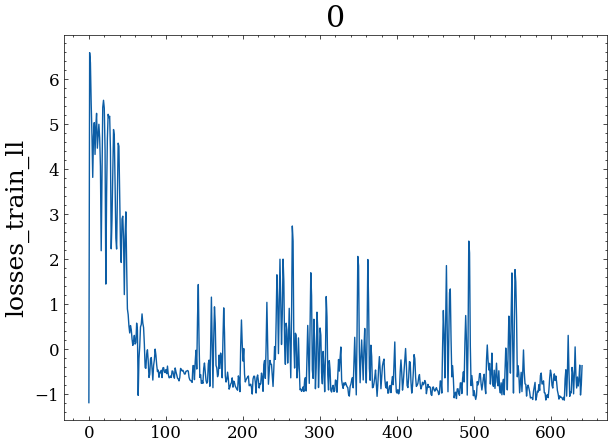

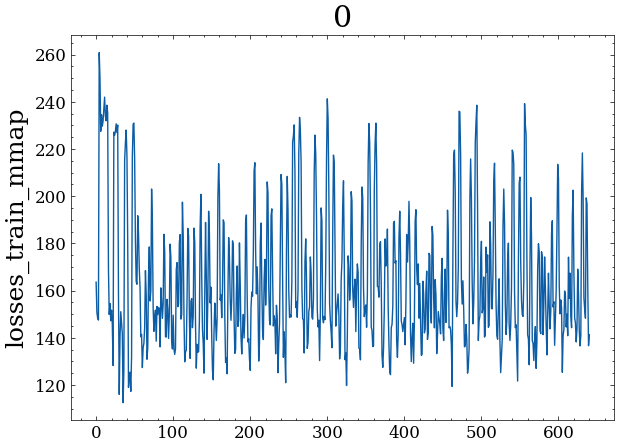

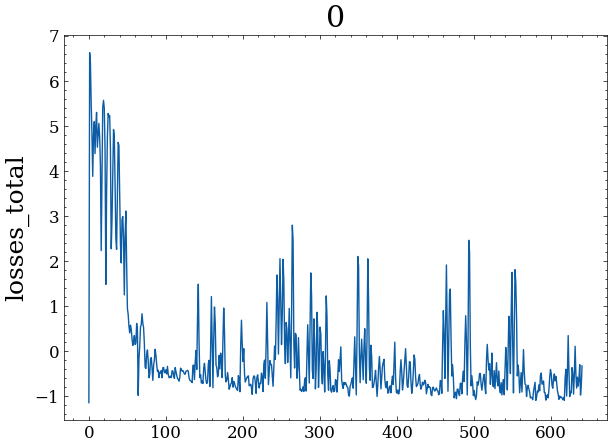

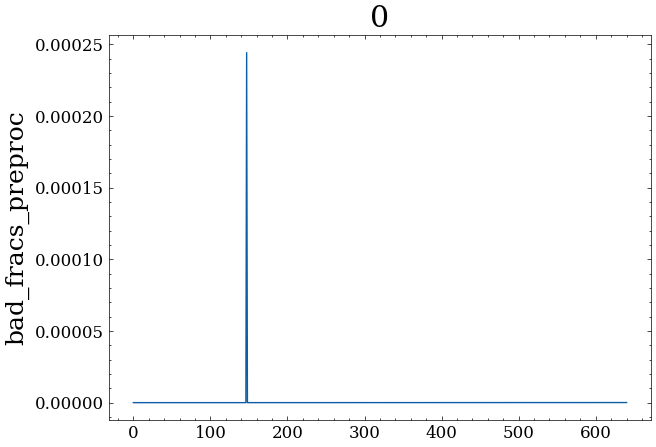

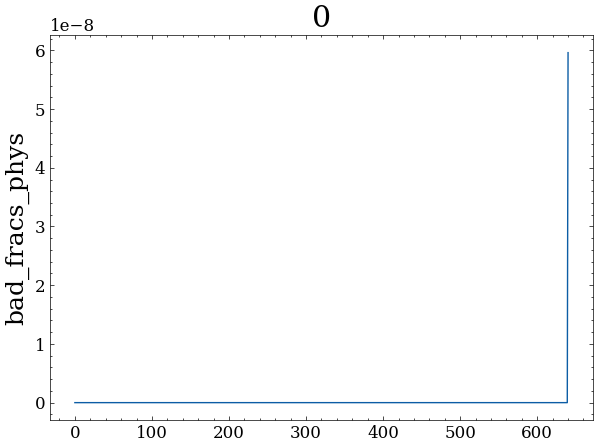

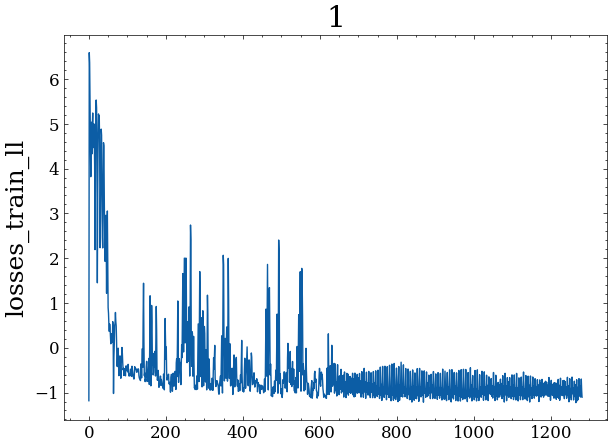

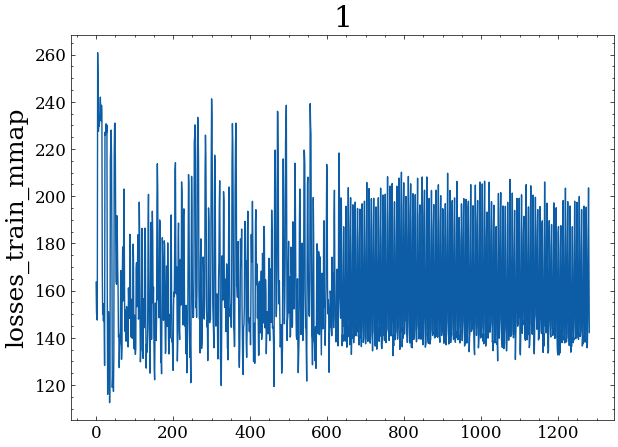

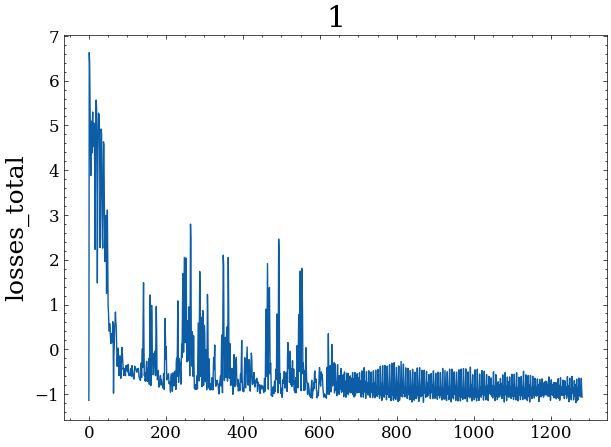

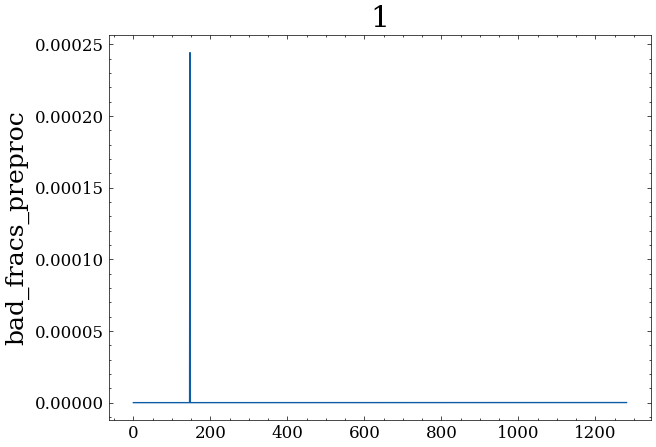

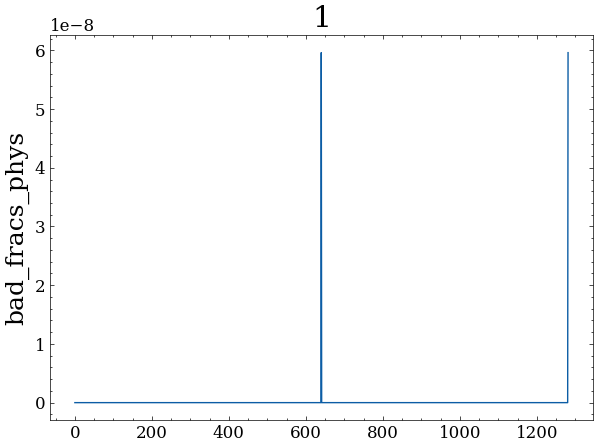

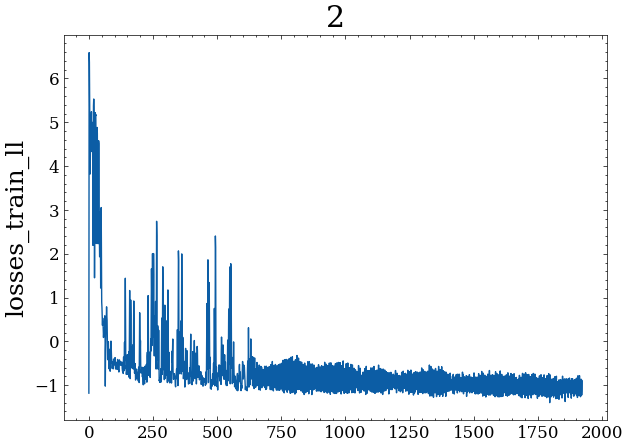

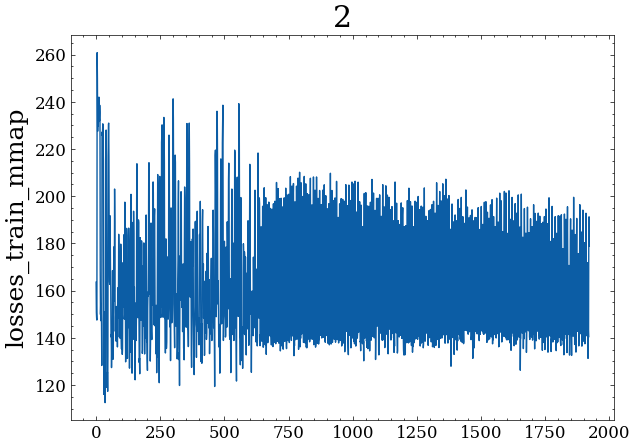

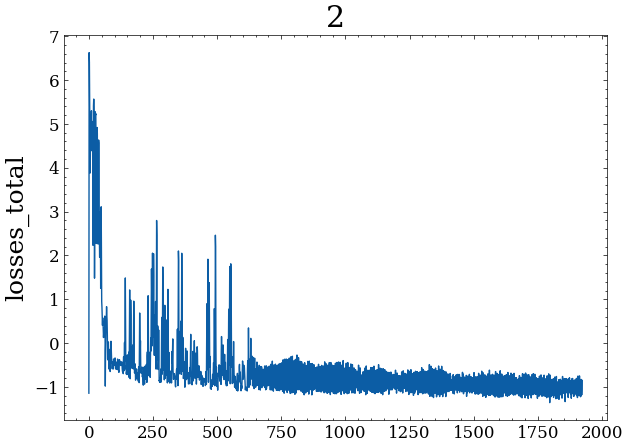

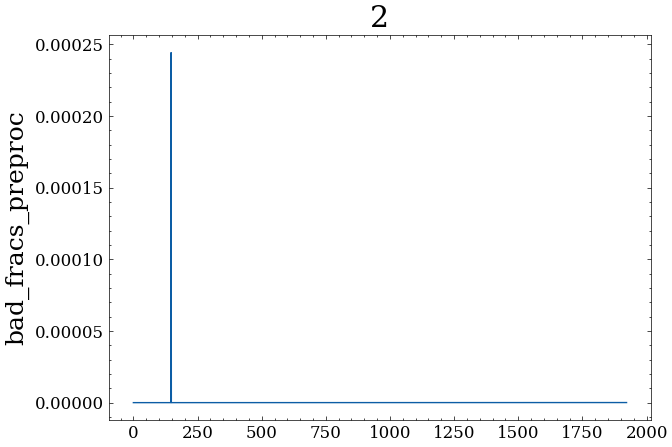

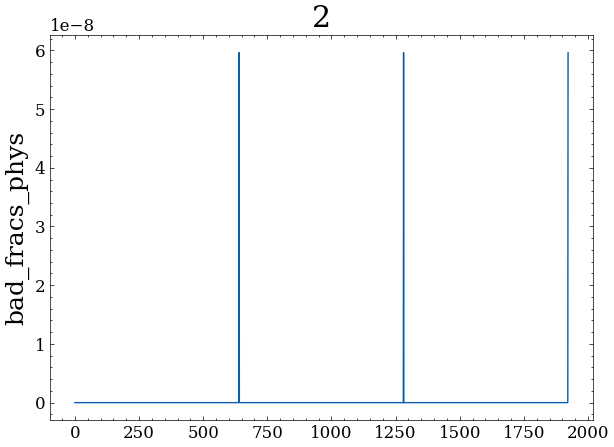

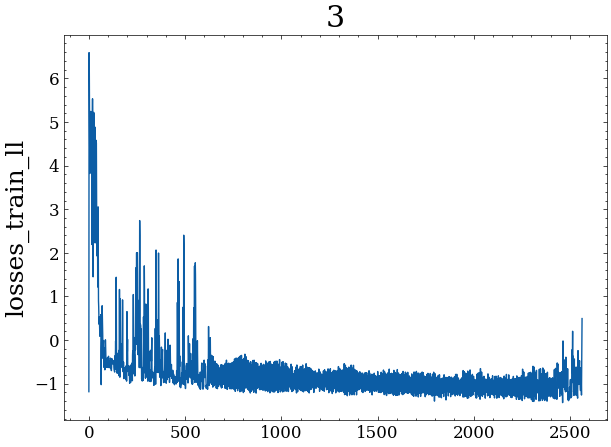

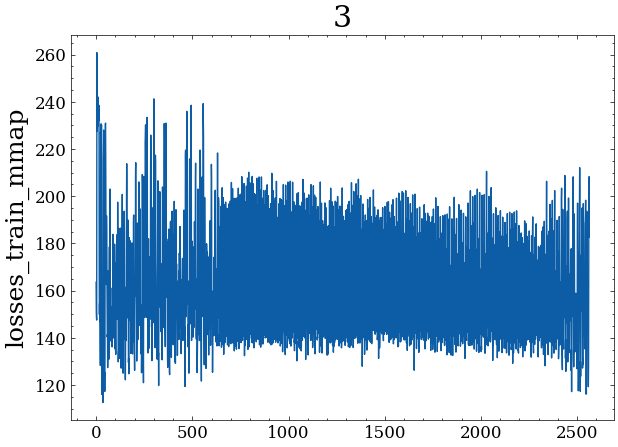

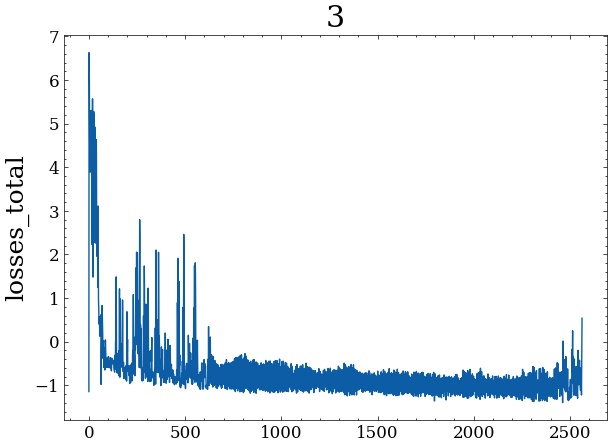

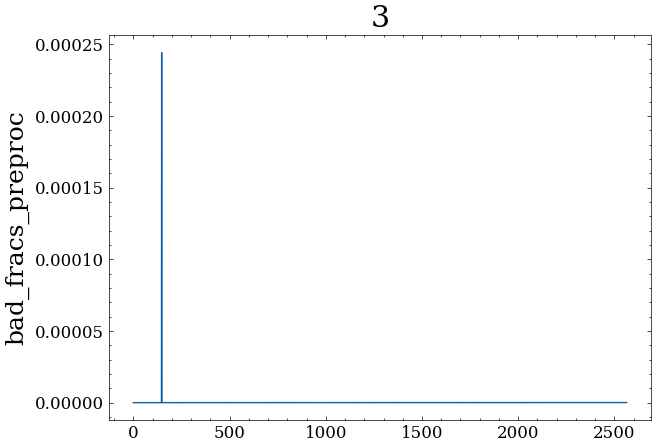

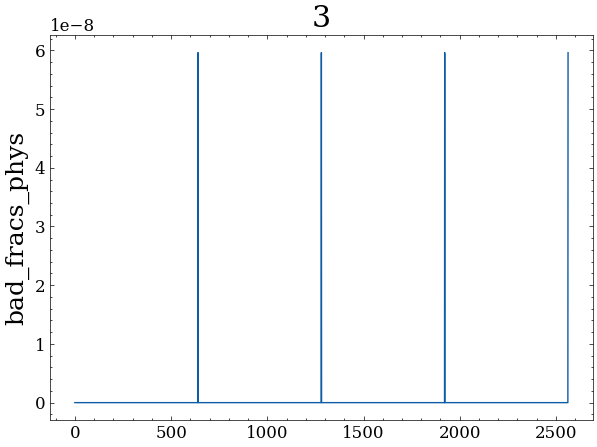

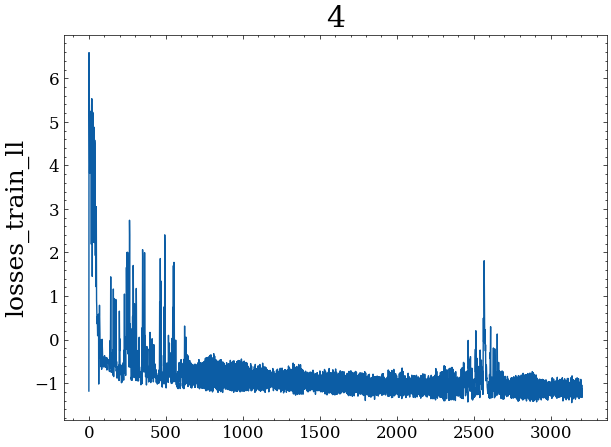

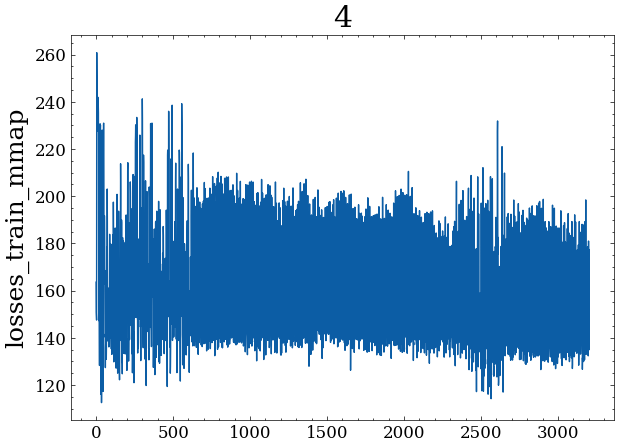

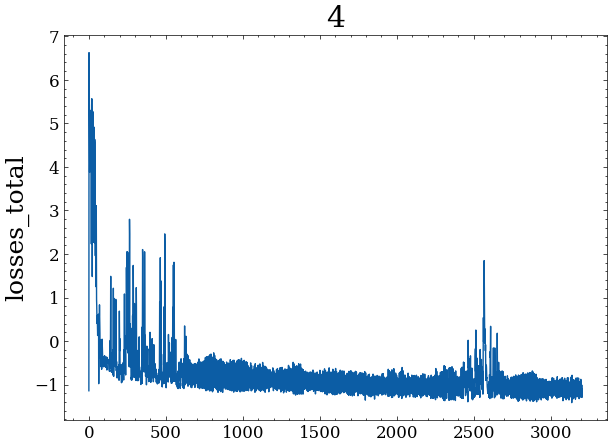

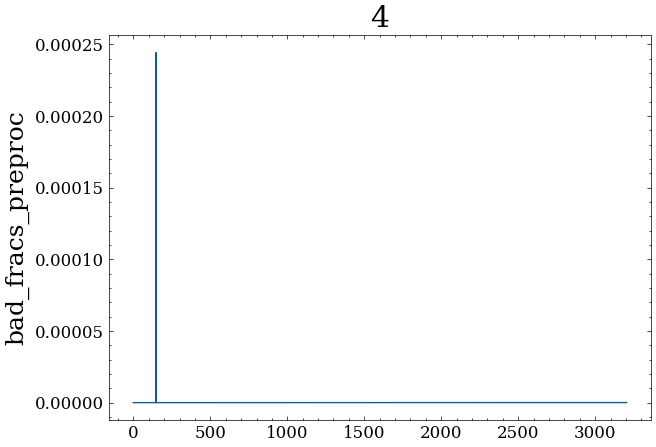

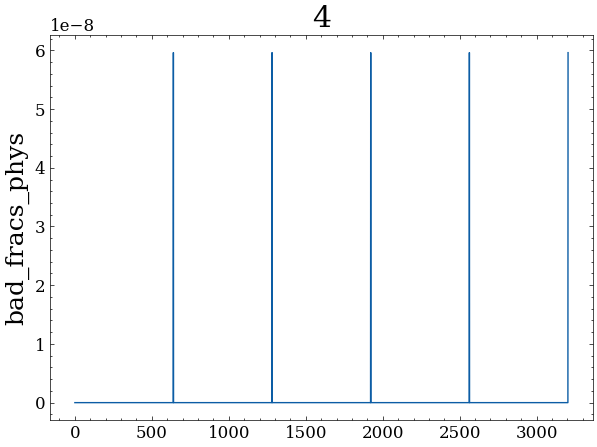

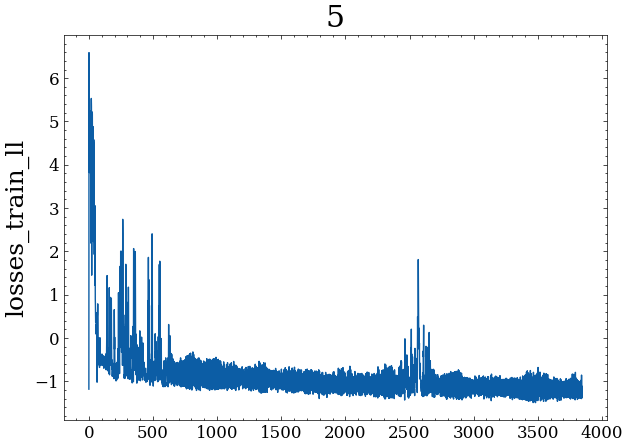

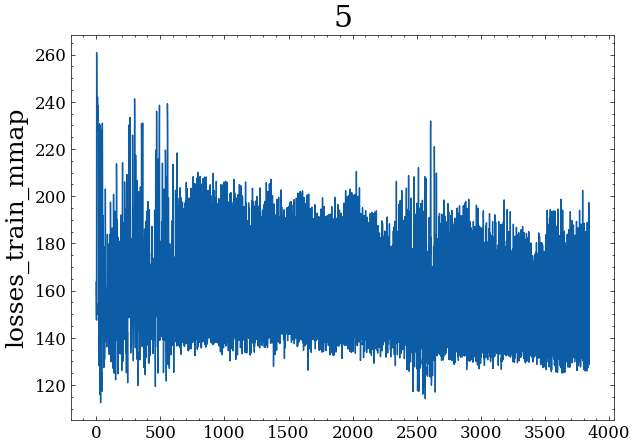

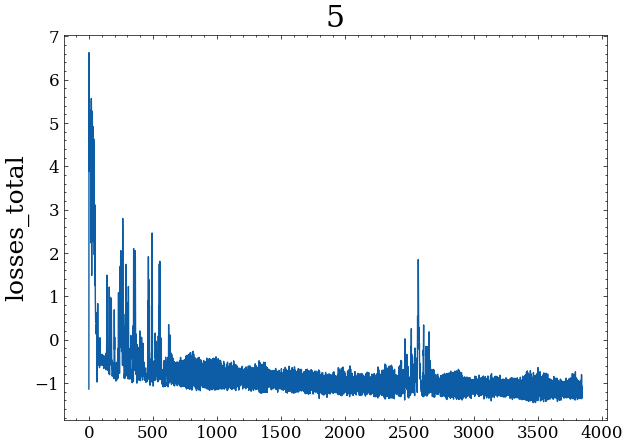

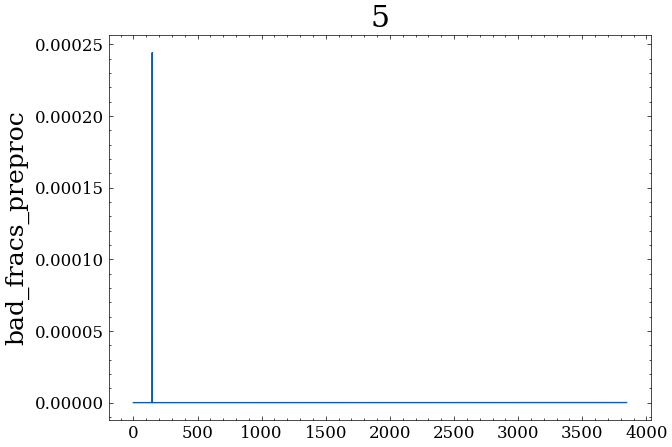

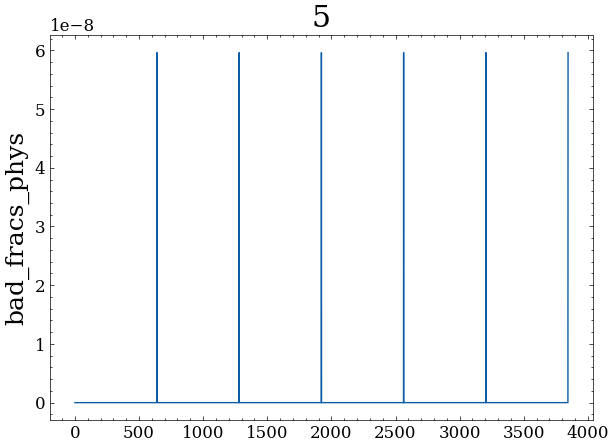

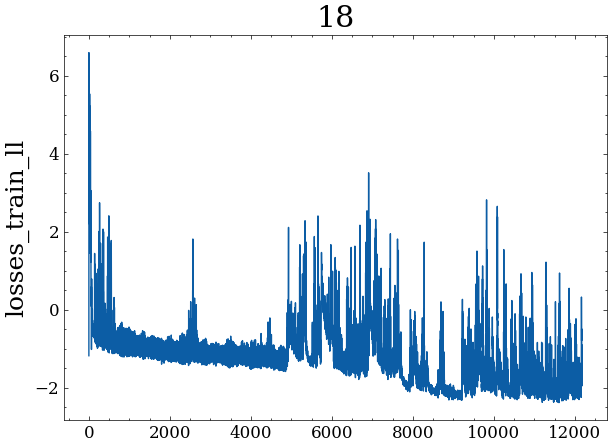

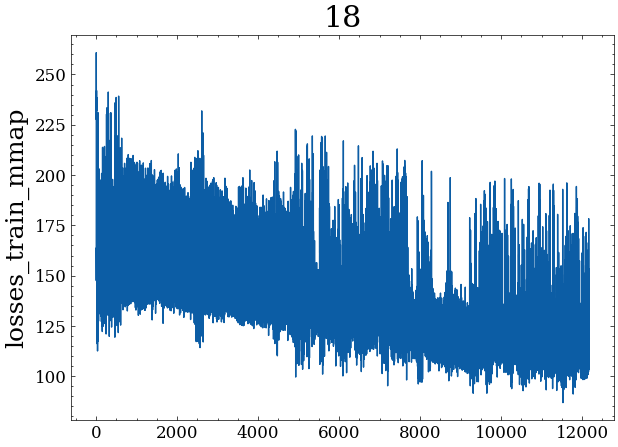

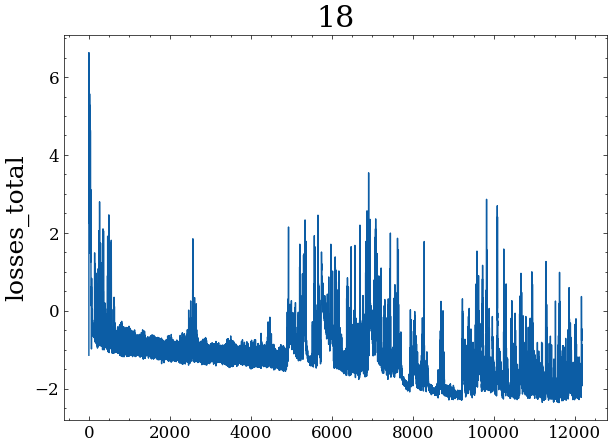

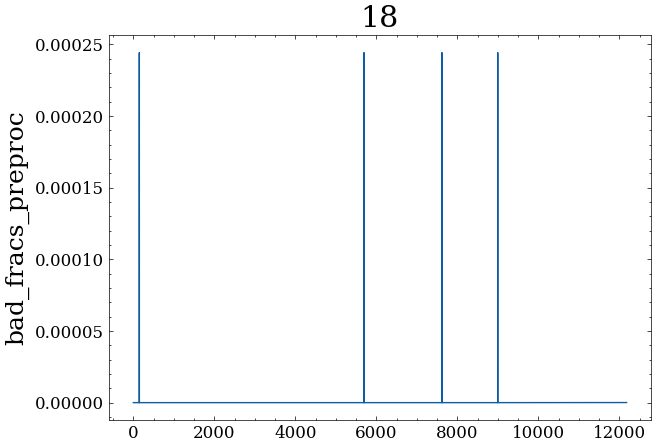

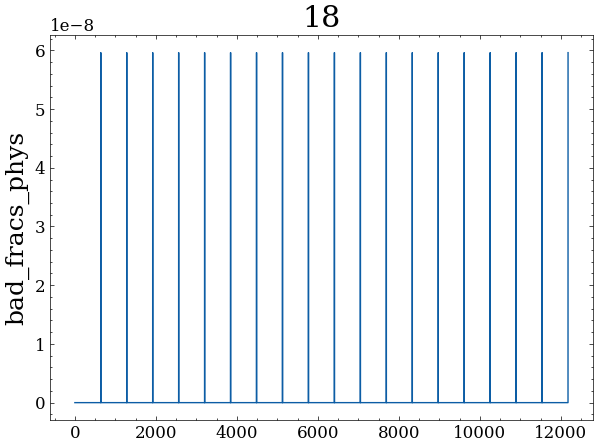

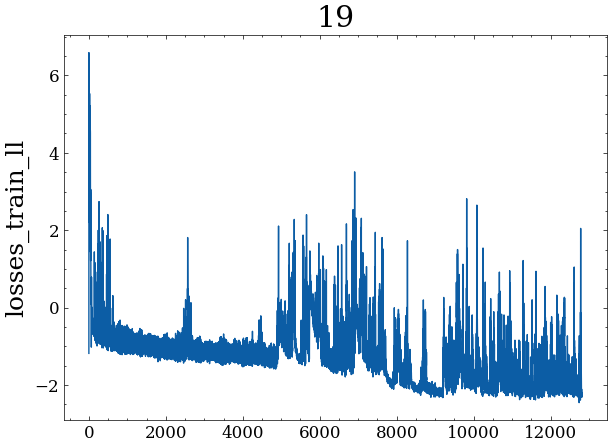

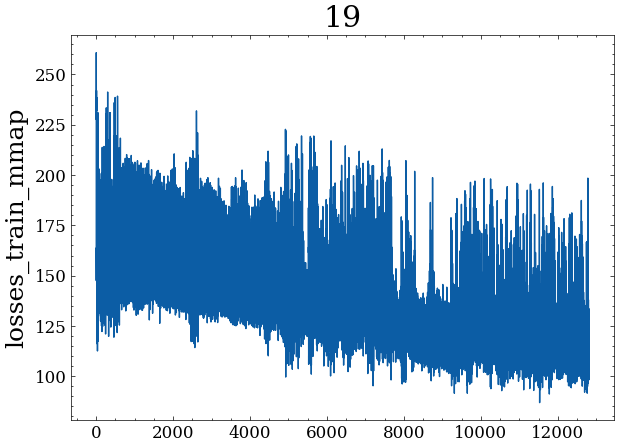

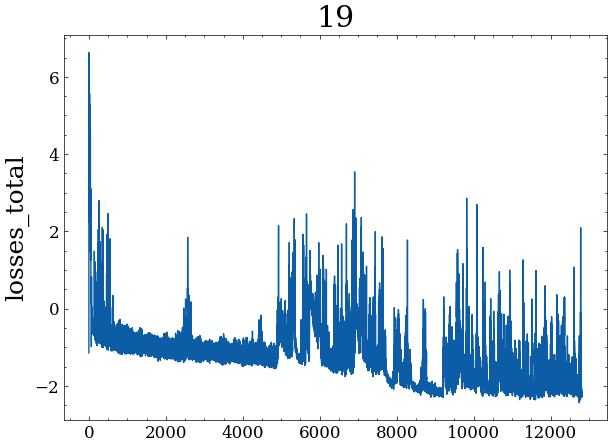

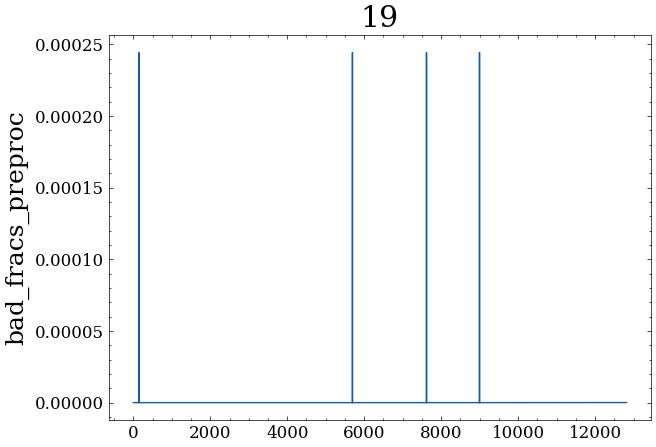

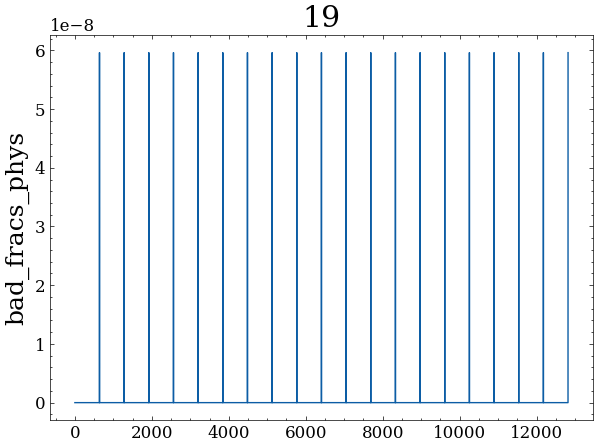

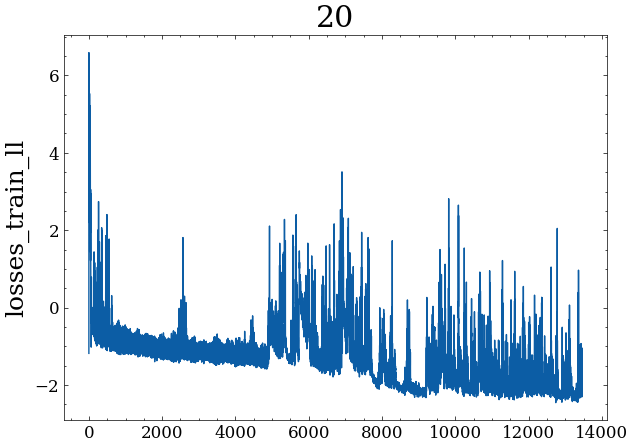

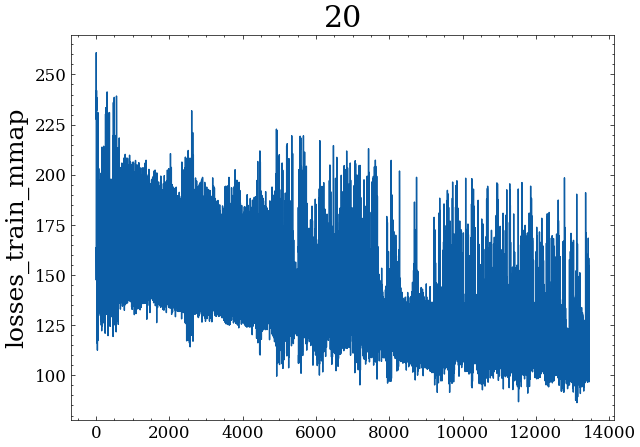

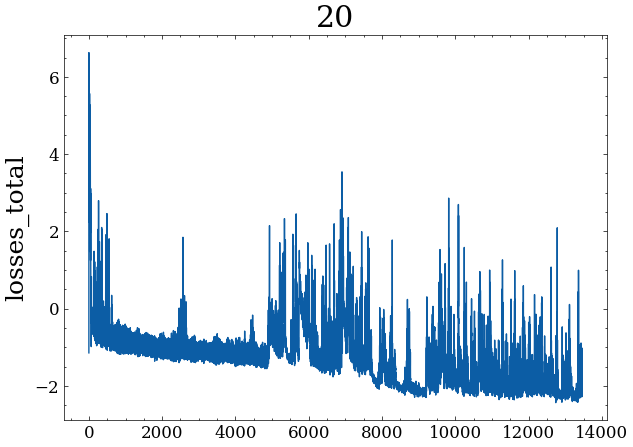

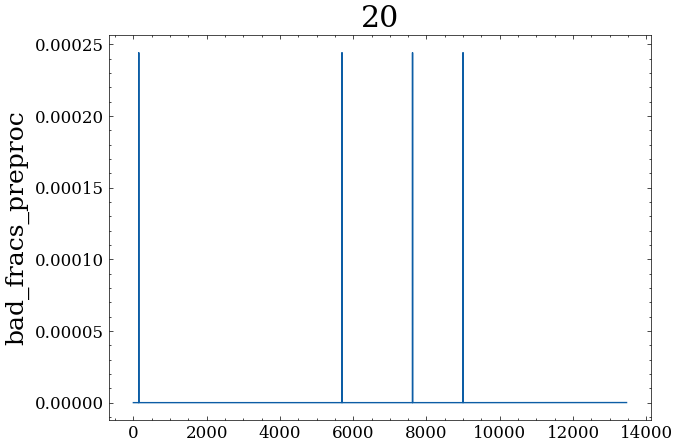

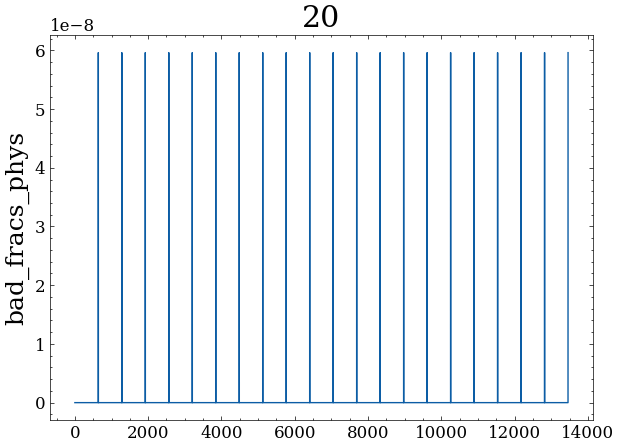

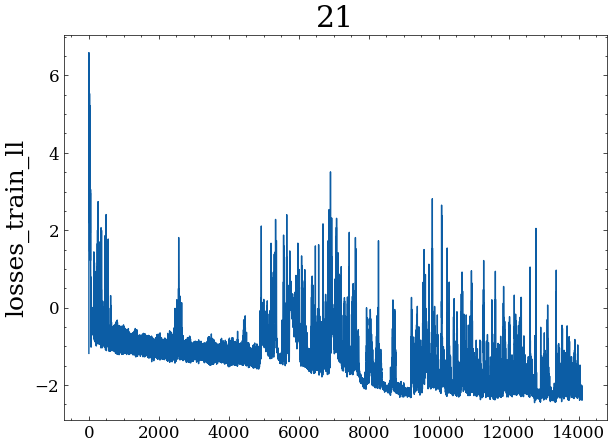

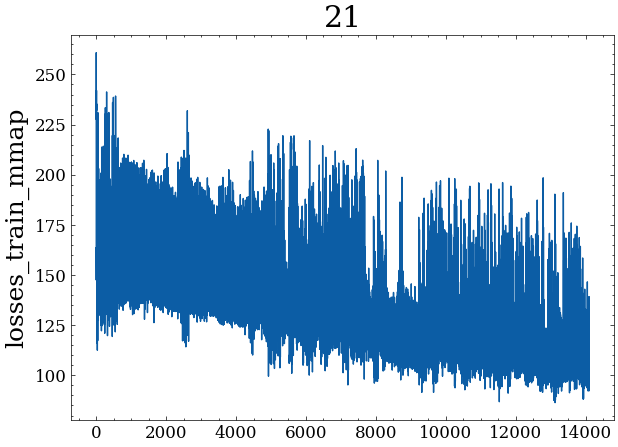

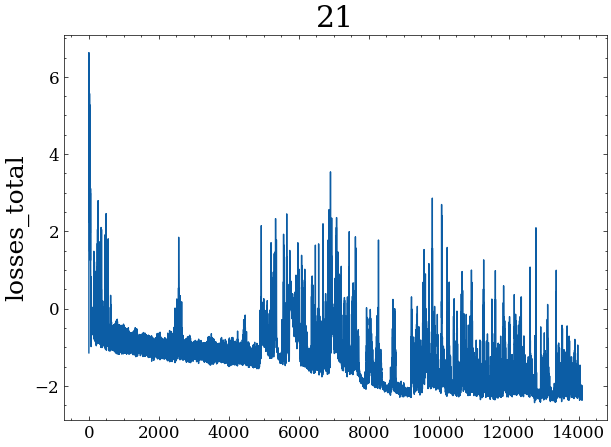

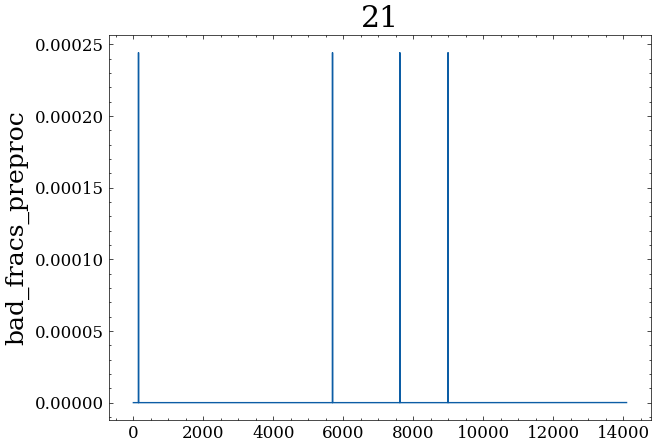

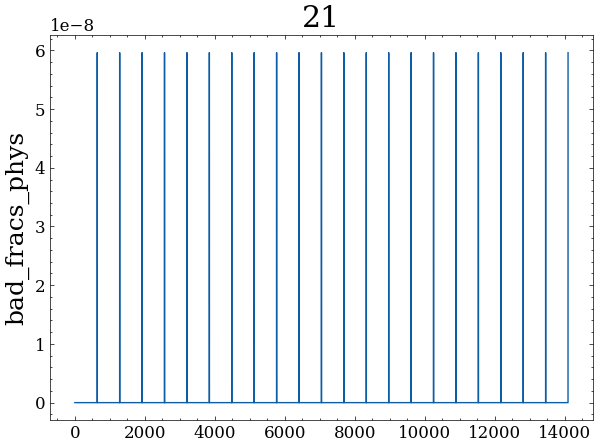

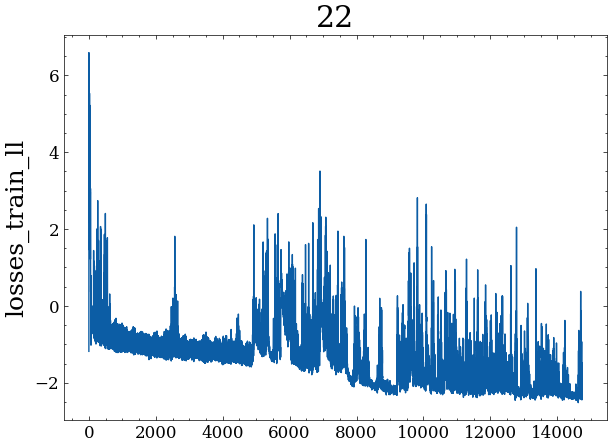

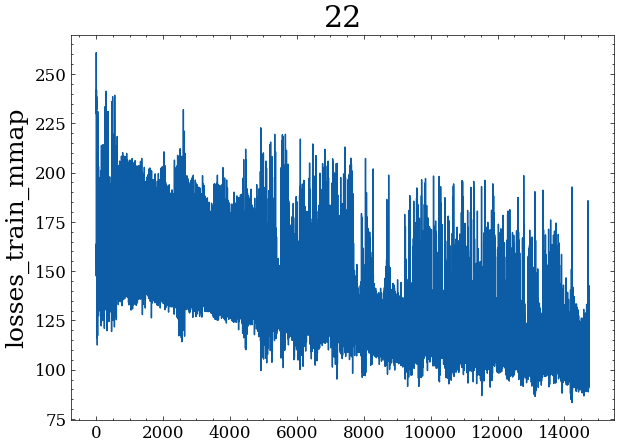

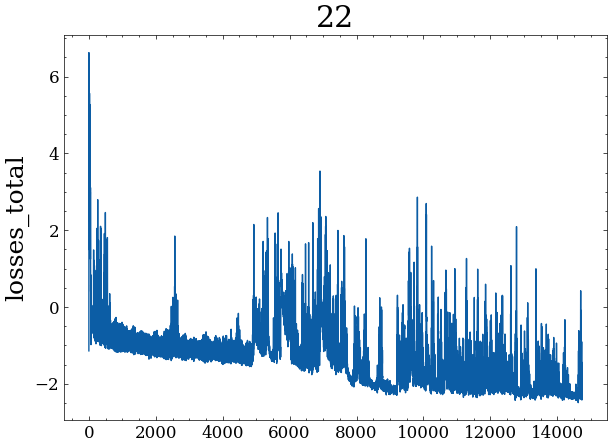

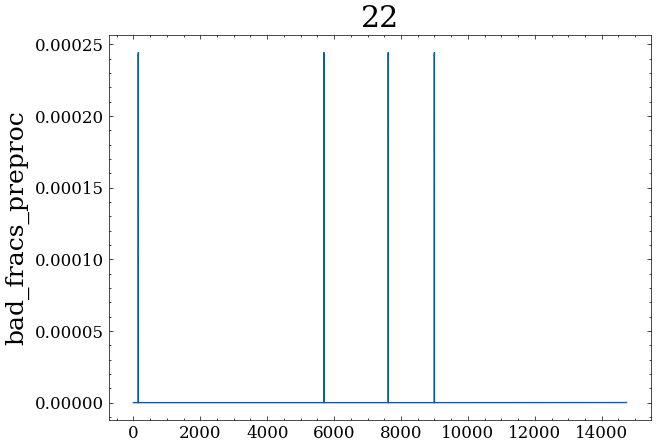

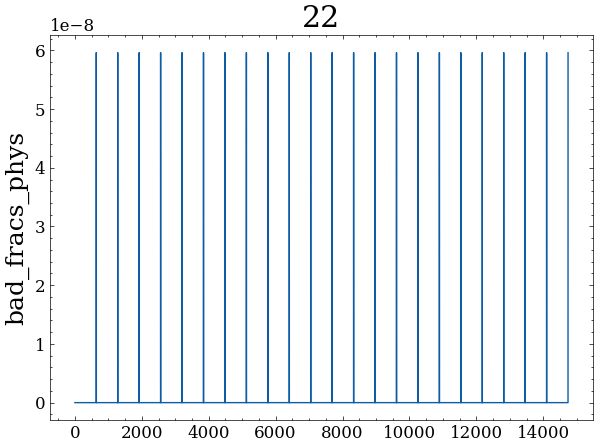

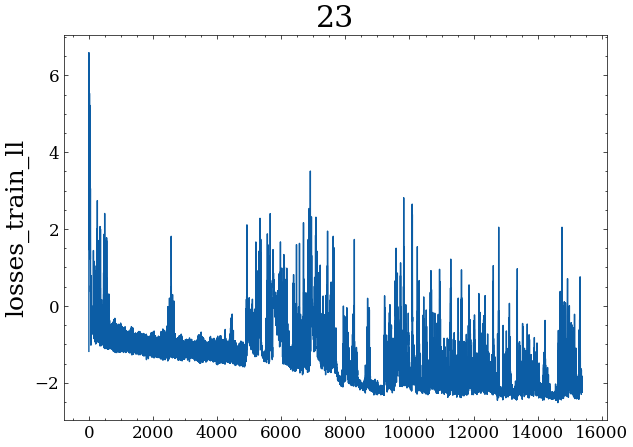

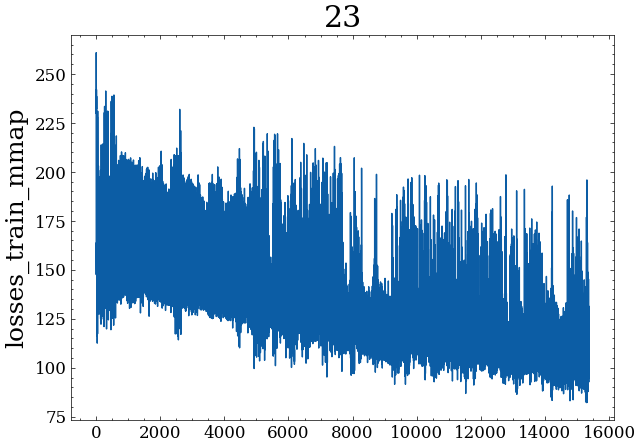

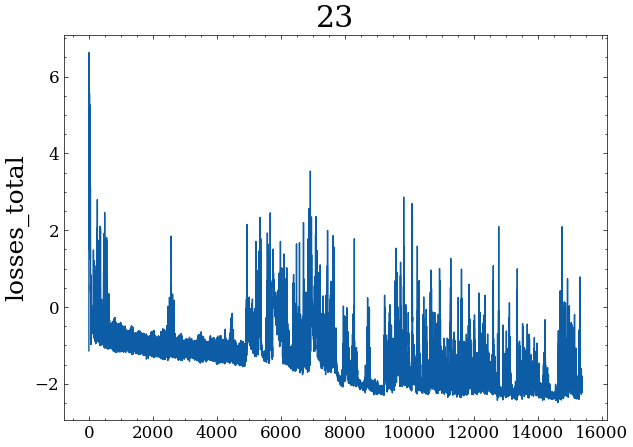

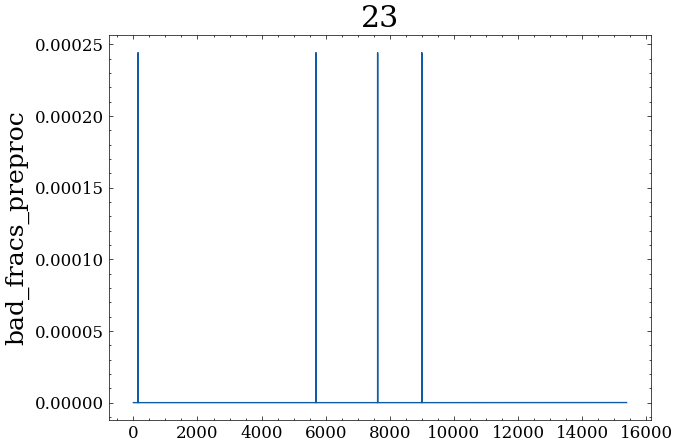

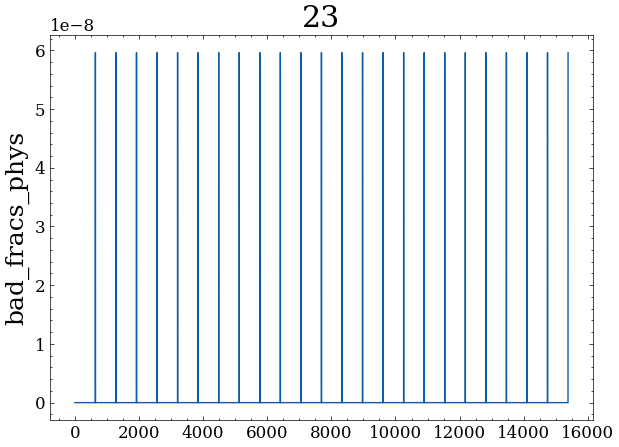

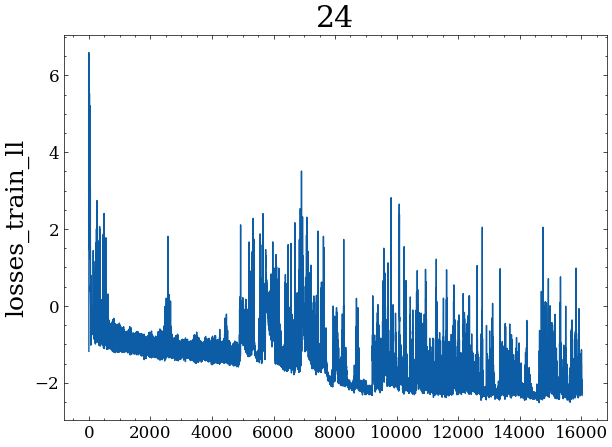

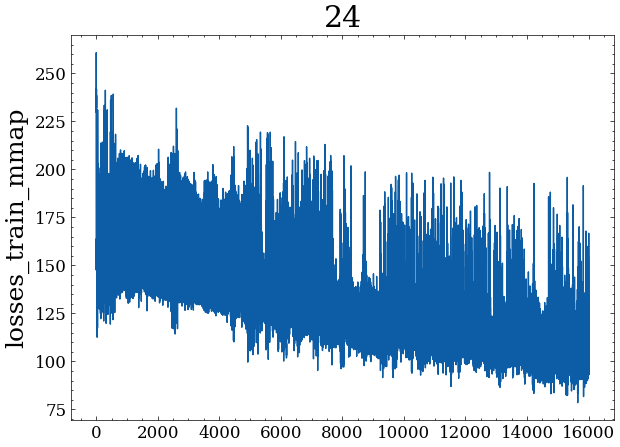

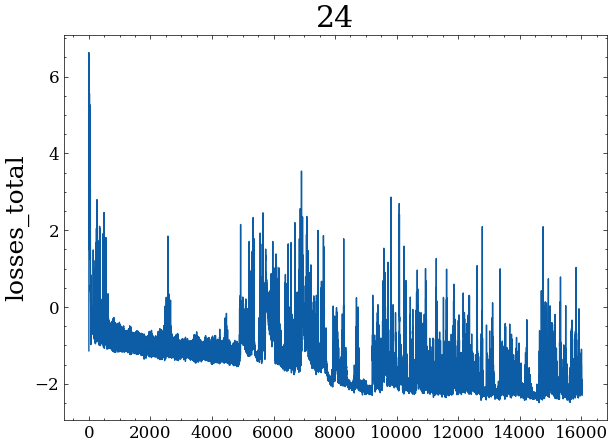

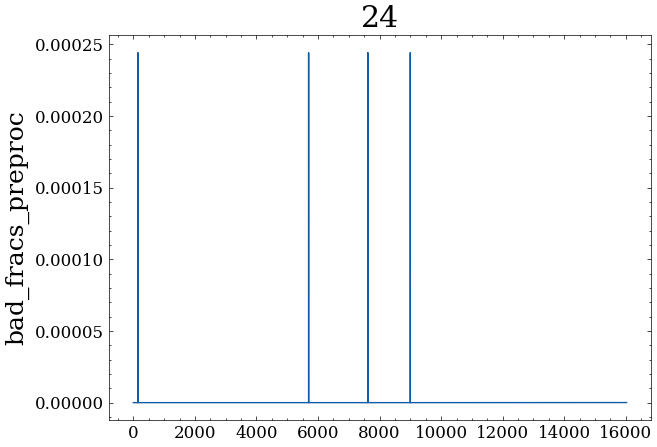

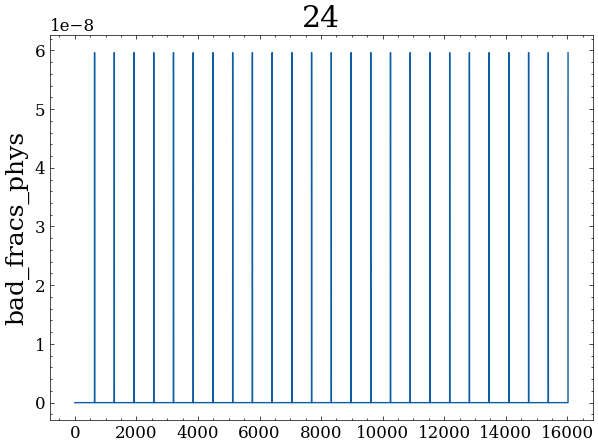

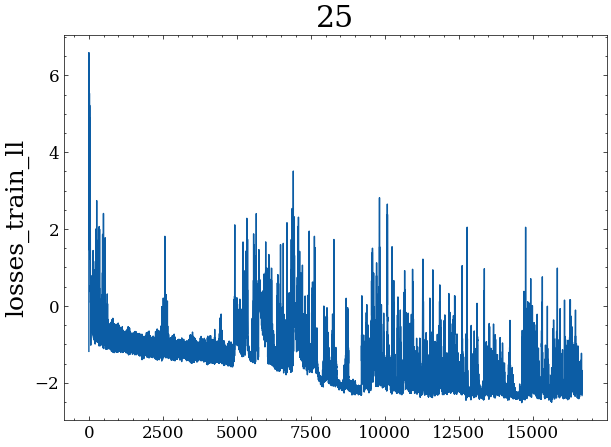

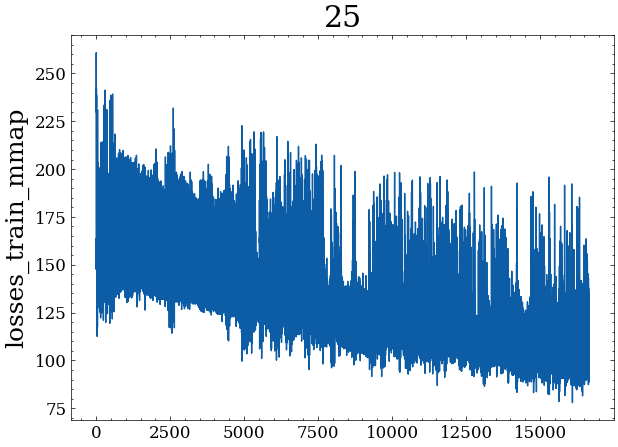

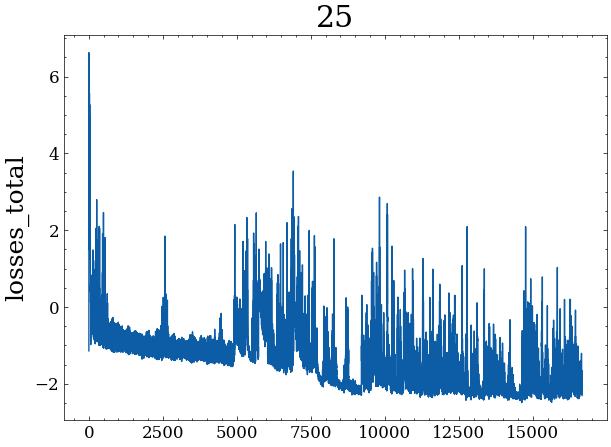

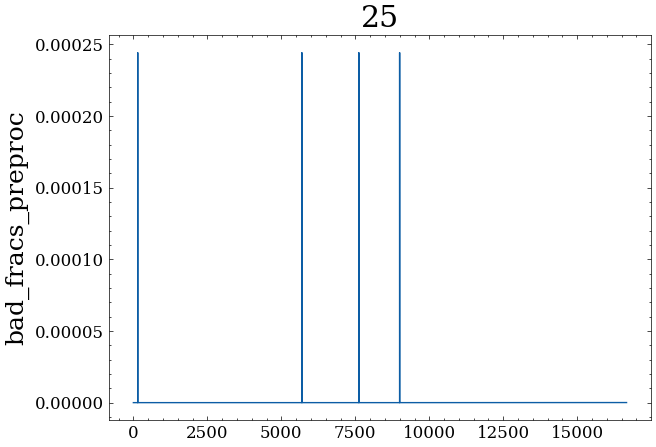

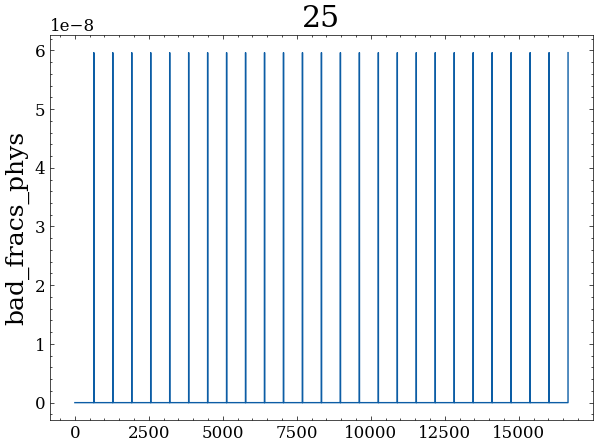

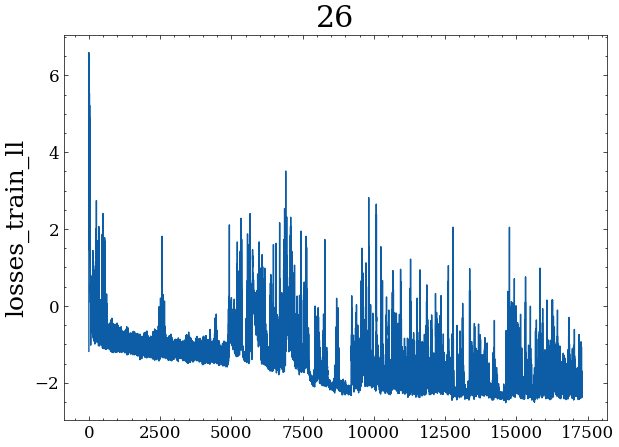

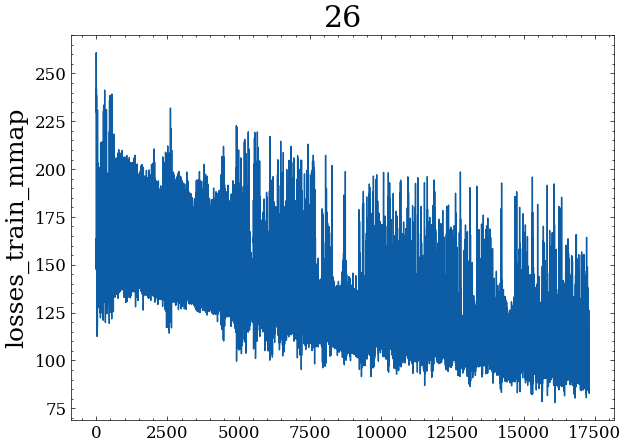

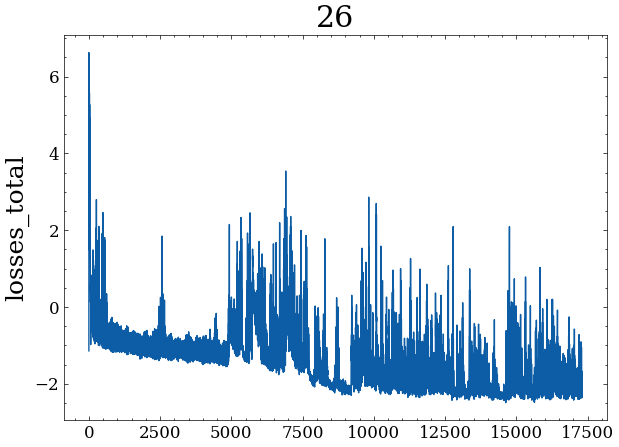

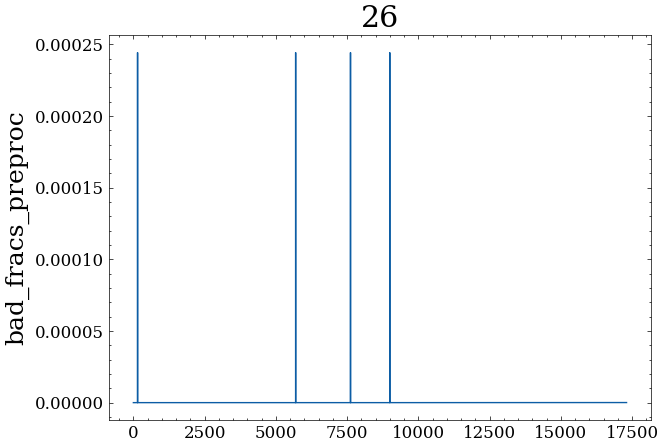

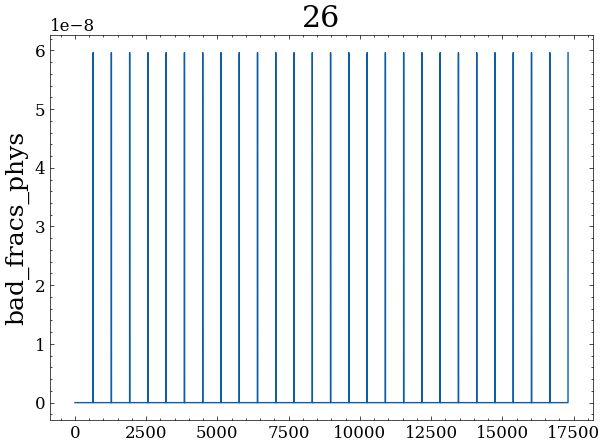

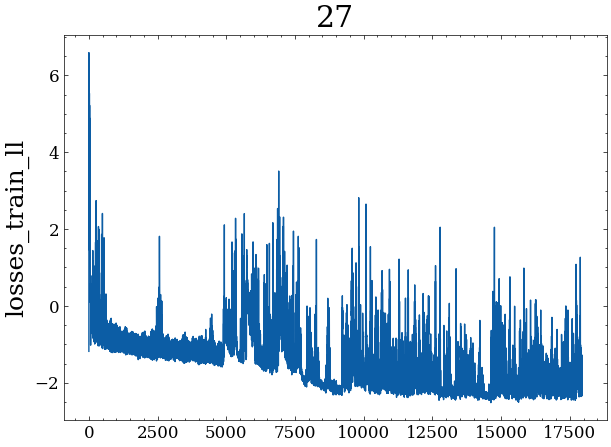

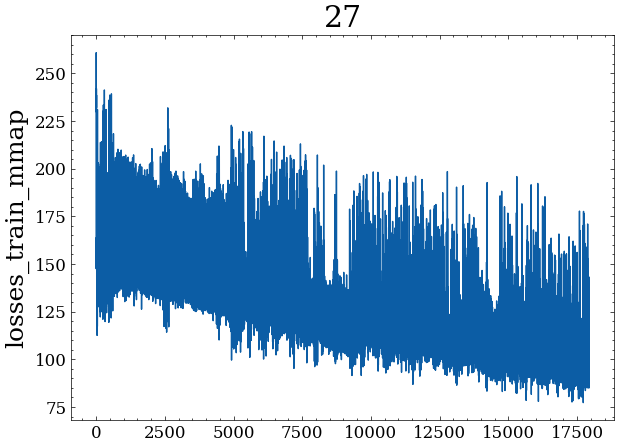

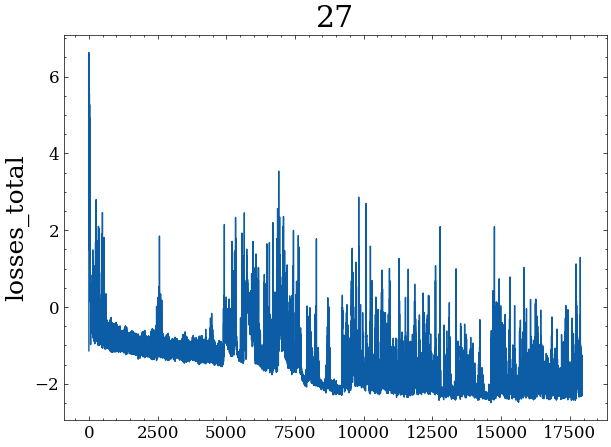

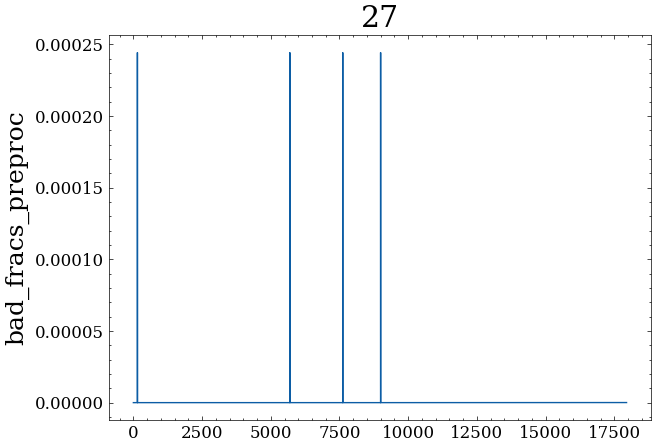

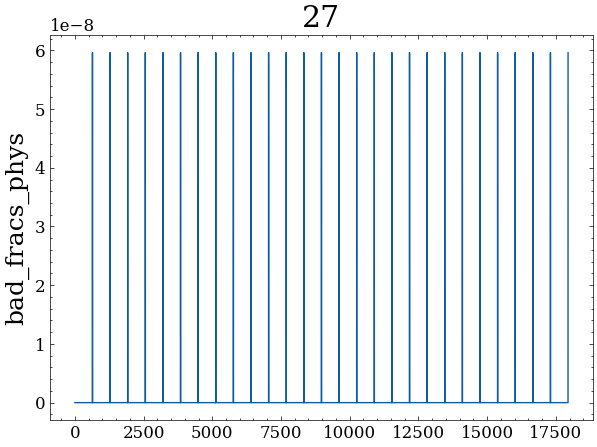

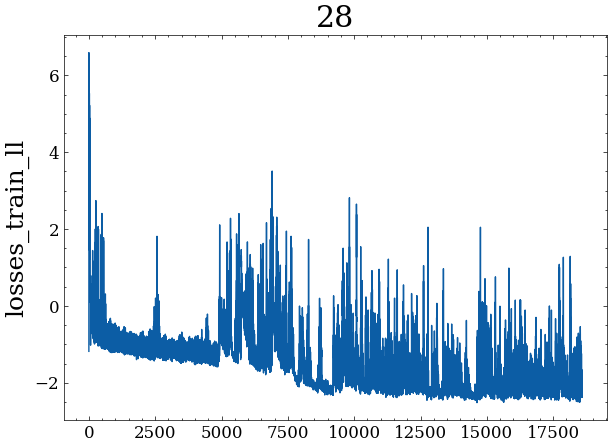

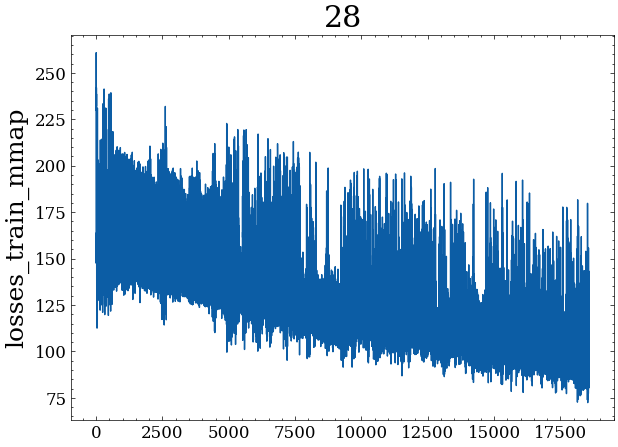

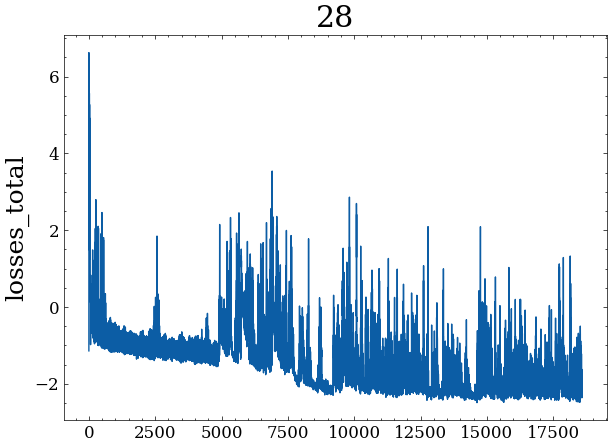

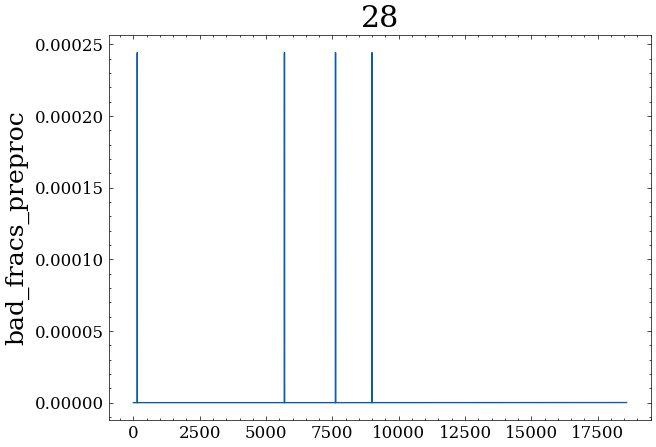

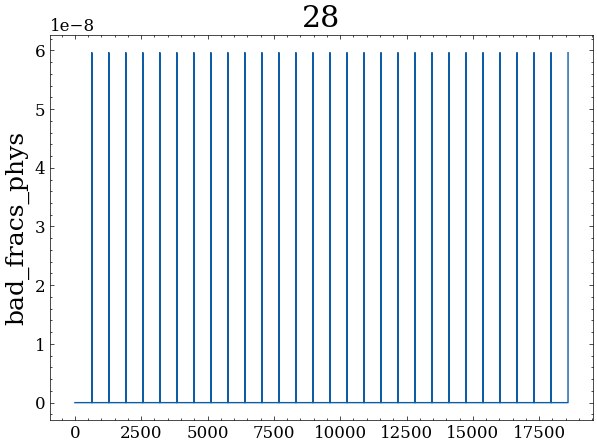

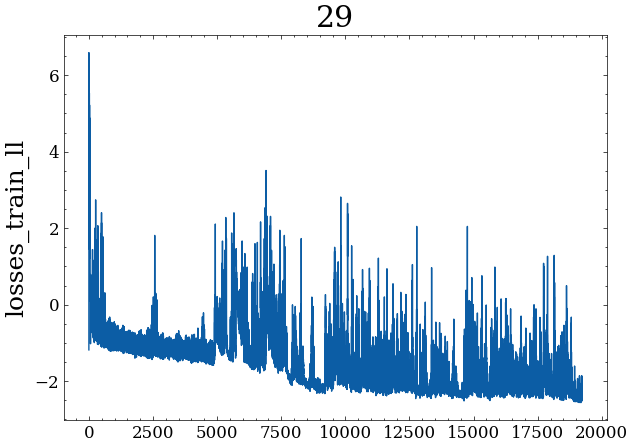

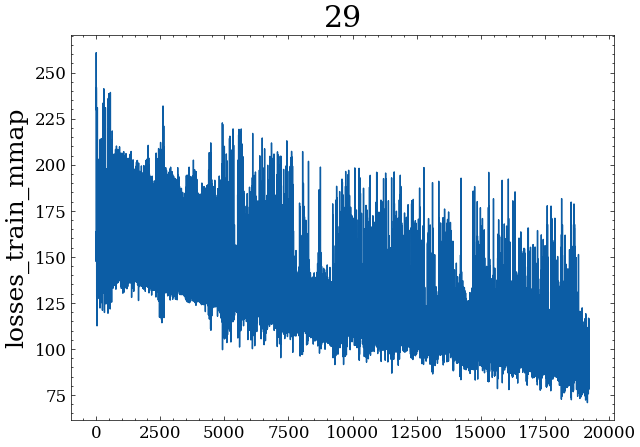

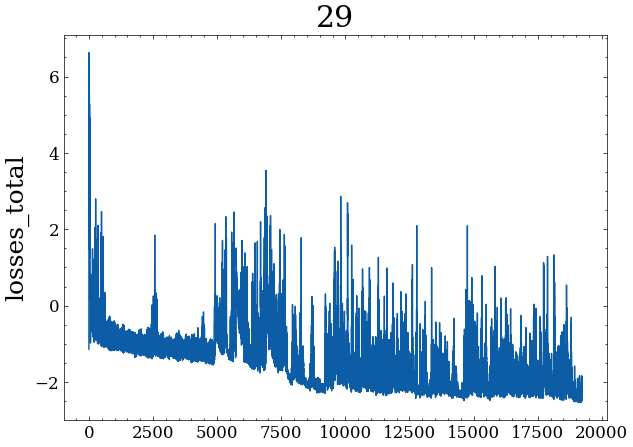

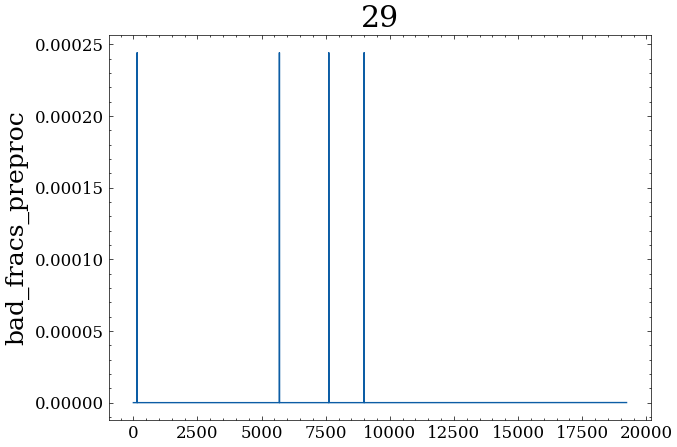

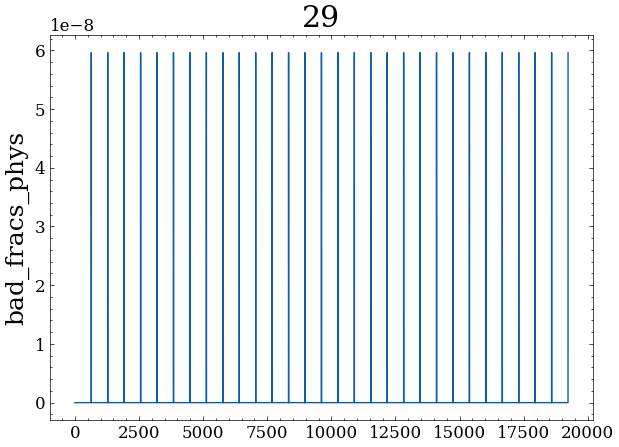

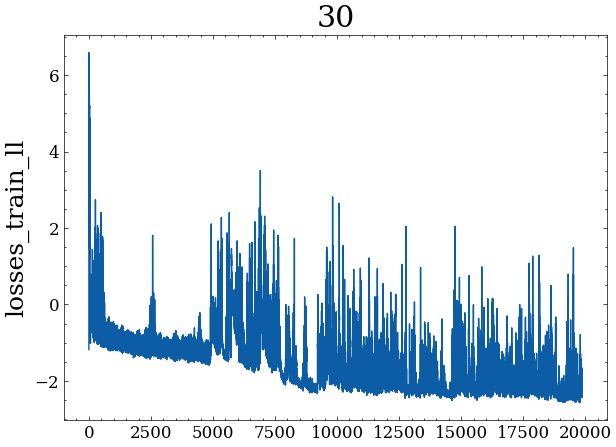

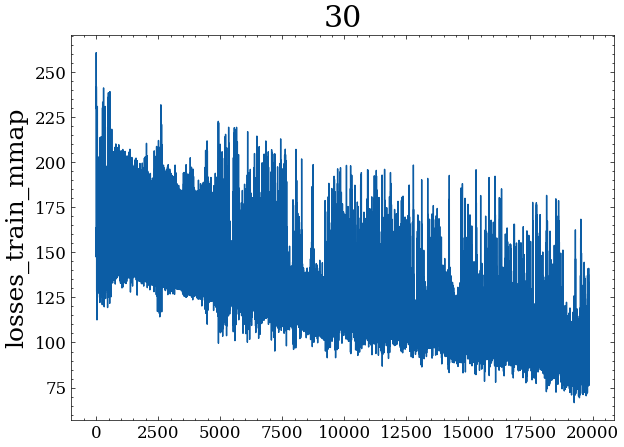

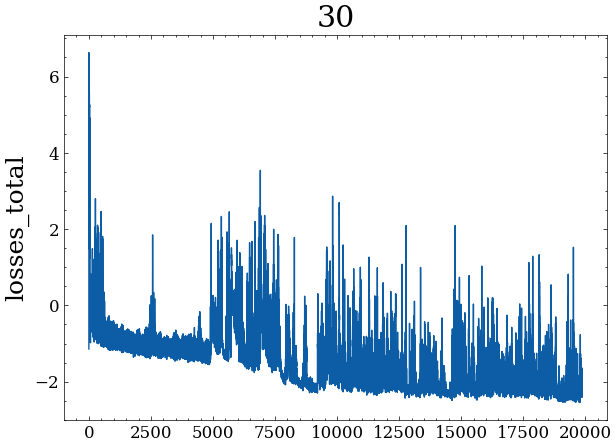

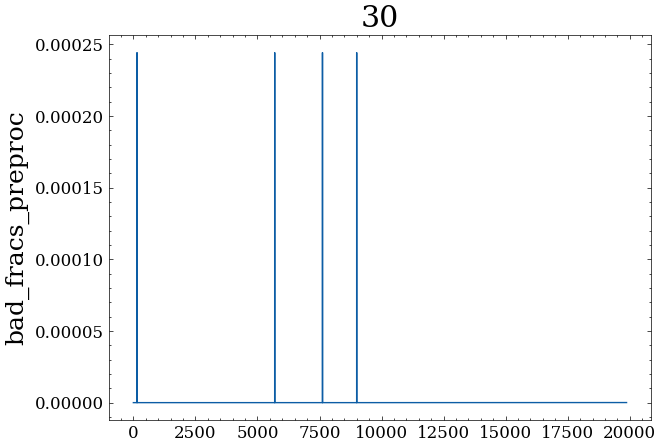

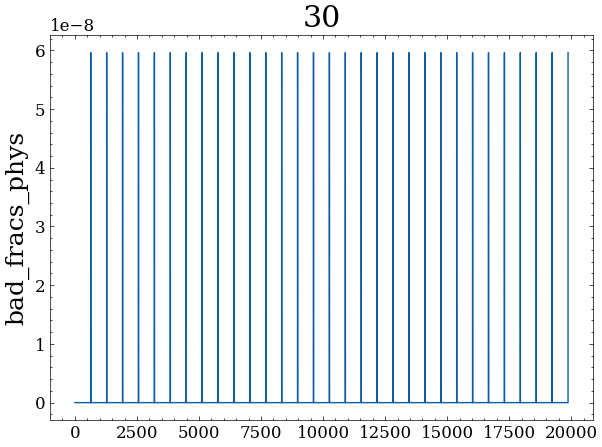

train batches:  69%|██████▉   | 442/641 [08:12<03:39,  1.10s/it, loss=-8.735e-01]

In [ ]:


if TRAIN_FLOW:
    print("Training flow...")

    # Train to maximize the log-likelihood
    optimizer = torch.optim.Adam(flow.parameters(), lr=LEARNING_RATE)

    # %%
    losses_train_ll, losses_train_mmap, losses_total = [], [], []
    bad_fracs_preproc, bad_fracs_phys = [], []
    best_val_loss = 1e10

    global_step = 11923

    for k in range(NUM_EPOCHS):

       

        train_losses, global_step = run_training_step(train_loader, k, global_step, is_val_step=False)

        torch.save(flow.state_dict(), f"{save_dir}/latest_good_step{global_step}.pt")
        losses_train_ll += train_losses["train/ll"]
        losses_train_mmap += train_losses["train/mmap"]
        losses_total += train_losses["train/total"]
        bad_fracs_preproc += train_losses["train/bad_fracs_preproc"]
        bad_fracs_phys += train_losses["train/bad_fracs_phys"]

        plt.figure()
        plt.plot(losses_train_ll)
        plt.ylabel("losses_train_ll")
        plt.title(k)
        plt.show()

        plt.figure()
        plt.plot(losses_train_mmap)
        plt.ylabel("losses_train_mmap")
        plt.title(k)
        plt.show()

        plt.figure()
        plt.plot(losses_total)
        plt.ylabel("losses_total")
        plt.title(k)
        plt.show()

        plt.figure()
        plt.plot(bad_fracs_preproc)
        plt.ylabel("bad_fracs_preproc")
        plt.title(k)
        plt.show()

        plt.figure()
        plt.plot(bad_fracs_phys)
        plt.ylabel("bad_fracs_phys")
        plt.title(k)
        plt.show()


        

        # with torch.no_grad():
        #     val_losses, _ = run_training_step(val_loader, k, global_step, is_val_step=True)


        
        #losses_train.append(train_losses["train/total"])
        # losses_val.append(val_losses["val/total"])
        
        # if val_losses["val/total"] < best_val_loss:
        #     best_val_loss = val_losses["val/total"]
        #     torch.save(flow.state_dict(), f"{save_dir}/test.pt")

        # if (k + 1) % PLOT_EPOCH_INTERVAL == 0:
        #     flow.eval()
        
        #     x_plot = next(iter(val_loader)).to(device).float()
        
        #     if NUM_COND_INPUTS > 0:
        #         x_plot_data = x_plot[:, :-NUM_COND_INPUTS]
        #         x_plot_context = x_plot[:, -NUM_COND_INPUTS:]
        #         factor = 5
        #         context_to_sample = x_plot_context.repeat_interleave(factor, dim=0)
        #         samples = sample_from_flow(flow, N=factor * len(x_plot_data), x_context=context_to_sample)
        #     else:
        #         factor = 5
        #         samples = sample_from_flow(flow, N=factor * len(x_plot))
        
        #     loc_data_dict = {
        #         # "data": inverse_preprocess_data(
        #         #     x_plot.detach().cpu().numpy(),
        #         #     save_dir,
        #         #     ZUKO_ID,
        #         #     NUM_COND_INPUTS,
        #         # ),
        #        "generated": inverse_preprocess_data(
        #             samples,
        #             save_dir,
        #             ZUKO_ID,
        #             NUM_COND_INPUTS,
        #         ),
        #     }
        #     plot_hists_1d(loc_data_dict, bins_dict, log_dims=log_vars, labels=feature_labels)
        #     plt.show()

        #     for key in loc_data_dict.keys():
        #         fig_samp, axes_samp = plot_corner_hist_2d(
        #             loc_data_dict[key],
        #             feature_labels=feature_labels,
        #             bins_dict=bins_dict,
        #             log_dims=log_vars,
        #             title= key,
        #         )
                
        #         plt.show()




In [ ]:
ckpt = torch.load(f"{save_dir}/bad_grad_batch_epoch4_step12901.pt", map_location="cpu")

# 1. Check if the issue is in x_gen_phys before the penalty
xgp = ckpt["x_gen_phys_full"]
print("x_gen_phys_full stats:")
print("  min:", xgp.min().item(), "max:", xgp.max().item())
print("  non-finite:", (~torch.isfinite(xgp)).sum().item())

# 2. Check how extreme the finite preproc samples are
xpp = ckpt["x_gen_preproc_full"]
finite = torch.isfinite(xpp).all(dim=1)
print("\nx_gen_preproc finite samples:")
print("  abs_max:", xpp[finite].abs().max().item())  # >5-10 is suspicious

# 3. Check what the material loss value actually was
print("\nmaterial_loss:", ckpt["material_loss"].item())
print("loss_ll:", ckpt["loss_ll"].item())
print("total_loss:", ckpt["total_loss"].item())

# 4. Find which gradient is first bad
gs = ckpt["grad_summary"]
for name, info in gs.items():
    if info["num_bad"] > 0:
        print(f"BAD: {name}  num_bad={info['num_bad']}  abs_max={info['abs_max']:.3e}")
        break